# <center> Análise de Backlog e Alerta de SLA </center>


O backlog da operação está crescendo há 3 semanas seguidas, isso significa que, vem aumentando o fluxo de trabalho que ocorre por tras da operação principal, o backlog da operação, as demandas estão crescendo e começou a criar um gargalo, por essa razão, entender a causa deste gargalo se torna essencial para o funcionamento de toda a operação.

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np
from datetime import datetime
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [78]:
# Carregar o arquivo CSV em pandas Dataframe
df_raw = pd.read_csv('M05_backlog_sla.csv')
df_raw

,Semana,Guias_Entrada,Guias_Processadas,Backlog_Acumulado,Auditores_Ativos,SLA_Percentual,TAT_Medio_Horas
0,Semana 1,1200,1250,150,12,92,36
1,Semana 2,1350,1280,220,12,89,39
2,Semana 3,1480,1300,400,11,83,44
3,Semana 4,1520,1250,670,10,76,51
4,Semana 5,1490,1200,960,10,71,55


In [79]:
# verificar o tipo de dados em cada coluna e a seguencia do indice no conjunto de dados 
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Semana             5 non-null      str  
 1   Guias_Entrada      5 non-null      int64
 2   Guias_Processadas  5 non-null      int64
 3   Backlog_Acumulado  5 non-null      int64
 4   Auditores_Ativos   5 non-null      int64
 5   SLA_Percentual     5 non-null      int64
 6   TAT_Medio_Horas    5 non-null      int64
dtypes: int64(6), str(1)
memory usage: 412.0 bytes


Os dados a serem analisados, são referentes ao fluxo de trabalho no backlog operacional e, que correspondem as ultimas 5 semanas, nesta base de dados estão presentes as seguintes variaveis: "Guias_Entrada", "Guias_Processadas",	"Backlog_Acumulado", "Auditores_Ativos", "SLA_Percentual" e "TAT_Medio_Horas" as quais compoem o fluxo operacional de backlog.


* ``Guias_Entrada``: Requisição inicial para começar o processamento da guias médica, é o primeiro contato para se requisitar os serviços, antes de abrir o processamento da guia.

* ``Guias_Processadas``: É a quantidade de guias processadas, desde sua abertura até o fechamento, processamento de ponta-a-ponta

* ``Backlog_Acumulado``: quantidade total de guias médicas que chegaram para auditoria mas ainda não foram processadas. Representa a fila acumulada de trabalho pendente — quanto maior o backlog, maior o risco de quebra de SLA.

* ``Auditores_Ativos``: É a quantidade de auditores ativamente trabalhando no processamento das guias

* ``SLA_Percentual``: É o percentual(%) de guias que foram processadas dentro do prazo estabelecido pela meta, que é de 48 horas, este é o percentual de guias que foram processdas denhtro da meta

* ``TAT_Medio_Horas``: É o tempo médio em horas, que se leva para processar uma guia do inicio ao fim, desde sua abertura ate o fechamento.



## Hipotese

* Menos auditores para processar mais guias = Desastre

## **Checagem para Limpeza dos Dados**

In [80]:
# Analisar dados nulos
df_raw.isnull().sum()

Semana               0
Guias_Entrada        0
Guias_Processadas    0
Backlog_Acumulado    0
Auditores_Ativos     0
SLA_Percentual       0
TAT_Medio_Horas      0
dtype: int64

O conjunto de dados não pussui valores nulos/faltantes

In [81]:
# Analisar dados duplicados
df_raw.duplicated().sum()

np.int64(0)

Não existem linhas em multiplicidade

## **Engenharia de Recursos**

* ``Saldo_Semanal``: É a diferença entre o que entra e o que sai naquela semana específica.  (Se for positivo, a fila acumula).
* ``Produtividade_Por_Auditor``: É a quantidade de guias processadas por auditor ativo naquela semana específica.


**OBS:** Este funcionado como um indicador de capacidade e eficiência, essa métrica é uma das mais valiosas, pois ela separa o efeito "tamanho da equipe" do efeito "ritmo de trabalho".

In [82]:
# Engenharia de Recursos para criar as métricas operacionais 
df_eng = df_raw.copy()

# Diferença entre o que entra e o que sai naquela semana específica.  (Se for positivo, a fila acumula).
df_eng['Saldo_Semanal'] = df_eng['Guias_Entrada'] - df_eng['Guias_Processadas']

# Quantidade de guias processadas por auditor ativo naquela semana específica.(Mede a eficiência individual)
df_eng['Produtividade_Por_Auditor'] = round(df_eng['Guias_Processadas'] / df_eng['Auditores_Ativos']).astype('Int64')

# Variação percentual do backlog semana a semana
df_eng['Variacao_Backlog_Pct'] = round(df_eng['Backlog_Acumulado'].pct_change() * 100, 2)

df_eng

,Semana,Guias_Entrada,Guias_Processadas,Backlog_Acumulado,Auditores_Ativos,SLA_Percentual,TAT_Medio_Horas,Saldo_Semanal,Produtividade_Por_Auditor,Variacao_Backlog_Pct
0,Semana 1,1200,1250,150,12,92,36,-50,104,NaN
1,Semana 2,1350,1280,220,12,89,39,70,107,46.67
2,Semana 3,1480,1300,400,11,83,44,180,118,81.82
3,Semana 4,1520,1250,670,10,76,51,270,125,67.50
4,Semana 5,1490,1200,960,10,71,55,290,120,43.28


Nesta verificação mais superficial, chama a atenção o fato que, na semana 1 existiam 12 auditores precessando guias, mas durante este periodo, até a semana 5, caiu para 10 auditores, revelando que ao decorrer das semanas houve uma redução na quantidade de auditores, já por outro lado, entre a semana 1 até a semena 5, aconteceu um aumento significativo na demanda por de aberturas de processamentos de guias, uma ação que foi inversa há quantidade de auditores.

## **Analise Exploratória**

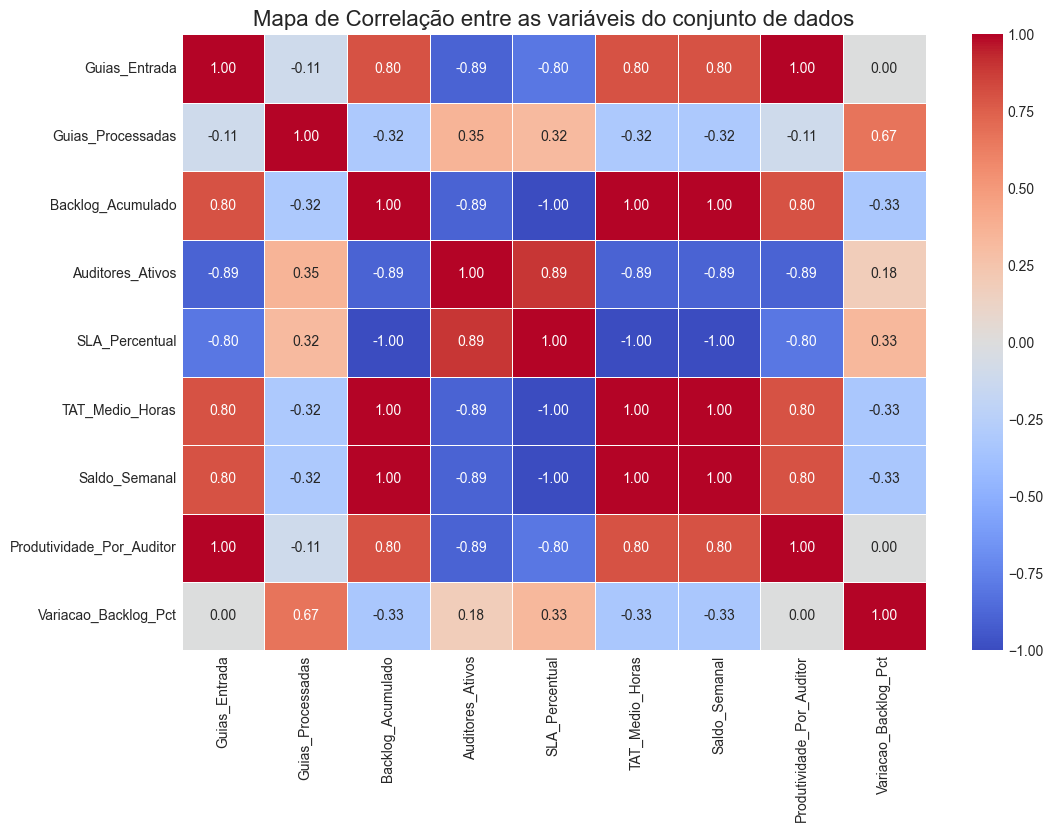

In [83]:
# Analise de correlçao entre as variaveis do conjunto de dados
plt.figure(figsize=(12, 8))
plt.title('Mapa de Correlação entre as variáveis do conjunto de dados', fontsize=16)
sns.heatmap(
    df_eng.drop(columns=['Semana']).corr(method='kendall'), # Aplicando metodo de correlação de Kendall pois a base de dados é pequena e não é normal.
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5)
plt.show()

Como o problema permeia entender o porquê está se acumulando guias no backlog da operação, se faz necessário entender e mensurar a correlação entre as próprias variáveis, e estas, com o backlog acumulado. Dentre as variáveis, quais as que afetam e de que maneira o acumulo de guias no backlog da operação?
 
Ao analisar a matriz de correlação, pode se entender de que modo cada variáveis presente no conjunto de dados se correlaciona com a outra, e constata se que as variáveis, 'Guias_Entrada', 'TAT_Medio_Horas, 'Saldo_Semanal' e 'Produtividade_Por_Auditor', todos estas possuem correlação diretamente proporcional (positiva) com a variável backlog acumulado, significando que, conforme aumentam os valores, em algumas destas variáveis, também poderá aumentar o valor na variável backlog acumulado. 

Na contramão desta ação, estão as variáveis, "Guias_Processadas", "Auditores_Ativos" e "SLA_Percentual", as quais são inversamente proporcionais (Negativa) a variável backlog acumulado, isso mostra que, quando os valores destas variáveis aumentam, poderá ocorrer também, diminuir os valores na variável backlog acumulado, e vice-versa.

Em continuidade com a analise, consigo destacar a correlação entre produtividade por auditor e o backlog acumulado, a medida que se aumenta o valor da produtividade por auditor, aproximadamente 80% do mesmo valor, também poderá ir aumentando no backlog acumulado, entretanto, se aumentar o valor da quantidade de auditores ativos, quase 90% desse valor, deverá ir diminuindo no backlog acumulado.

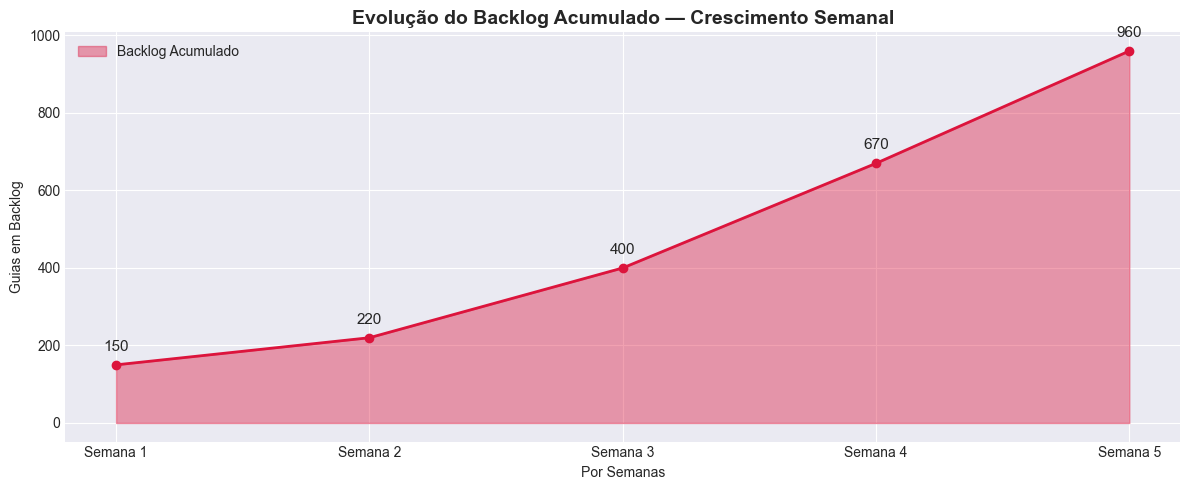

In [ ]:
# Evolução do Backlog
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(df_eng['Semana'], df_eng['Backlog_Acumulado'], 
                alpha=0.4, color='crimson', label='Backlog Acumulado')
ax.plot(df_eng['Semana'], df_eng['Backlog_Acumulado'], 
        color='crimson', marker='o', linewidth=2)
# Adicionar valores nos pontos
for i, val in enumerate(df_eng['Backlog_Acumulado']):
    ax.annotate(f'{val}', (df_eng['Semana'][i], val), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=11)
ax.set_title('Evolução do Backlog Acumulado — Crescimento Semanal', fontsize=14, fontweight='bold')
ax.set_xlabel('Por Semanas')
ax.set_ylabel('Guias em Backlog')
ax.legend()
plt.tight_layout()
plt.show()

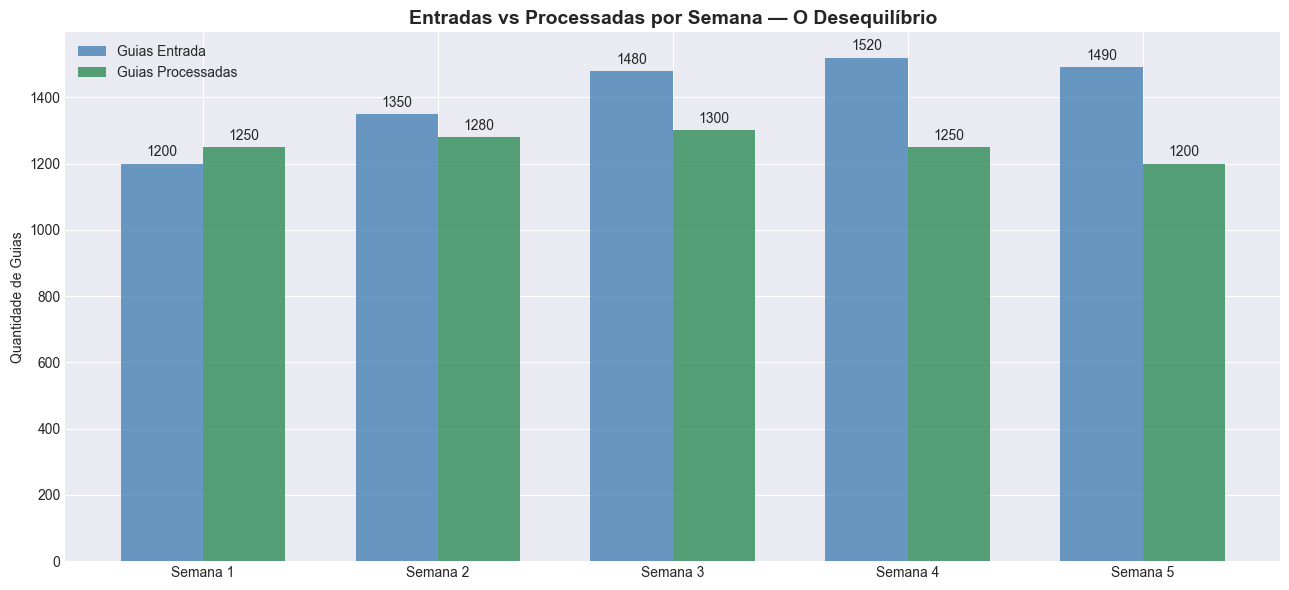

In [ ]:
# Entradas vs Processadas
x = np.arange(len(df_eng['Semana']))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(
    x - width/2, 
    df_eng['Guias_Entrada'],
    width,
    label='Guias Entrada', 
    color='steelblue', 
    alpha=0.8)

bars2 = ax.bar(
    x + width/2,
    df_eng['Guias_Processadas'],
    width,
    label='Guias Processadas',
    color='seagreen',
    alpha=0.8)

ax.set_title('Entradas vs Processadas por Semana — O Desequilíbrio', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_eng['Semana'])
ax.set_ylabel('Quantidade de Guias')
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
plt.tight_layout()
plt.show()

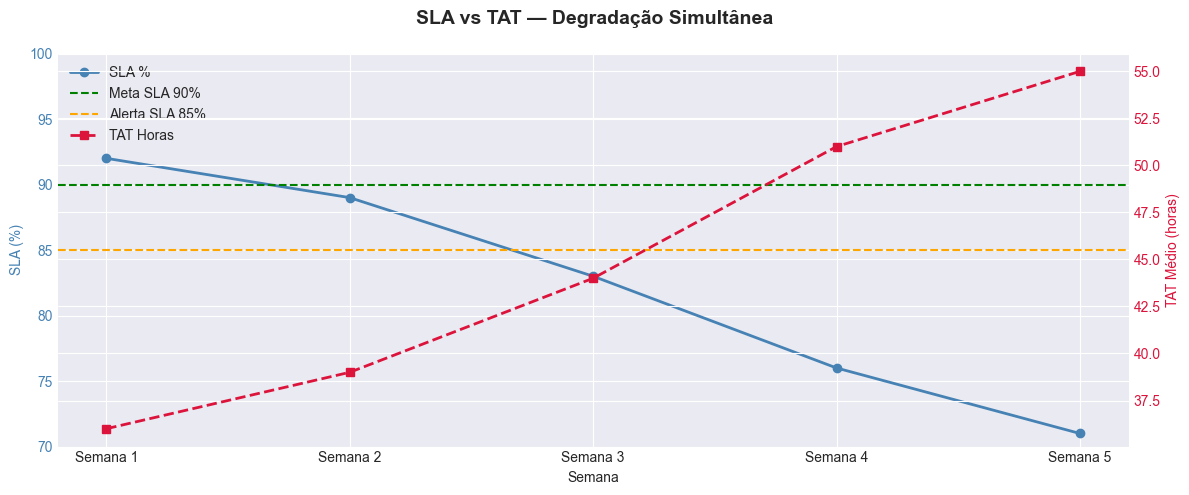

In [96]:
# SLA e TAT com dois eixos
fig, ax1 = plt.subplots(figsize=(12, 5))
# Eixo esquerdo — SLA
color_sla = 'steelblue'
ax1.set_xlabel('Semana')
ax1.set_ylabel('SLA (%)', color=color_sla)
ax1.plot(df_eng['Semana'], df_eng['SLA_Percentual'], 
         color=color_sla, marker='o', linewidth=2, label='SLA %')
ax1.axhline(y=90, color='green', linestyle='--', linewidth=1.5, label='Meta SLA 90%')
ax1.axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Alerta SLA 85%')
ax1.tick_params(axis='y', labelcolor=color_sla)
ax1.set_ylim(70, 100)
# Eixo direito — TAT
ax2 = ax1.twinx()
color_tat = 'crimson'
ax2.set_ylabel('TAT Médio (horas)', color=color_tat)
ax2.plot(df_eng['Semana'], df_eng['TAT_Medio_Horas'], 
         color=color_tat, marker='s', linewidth=2, linestyle='--', label='TAT Horas')
ax2.tick_params(axis='y', labelcolor=color_tat)
fig.suptitle('SLA vs TAT — Degradação Simultânea', fontsize=14, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

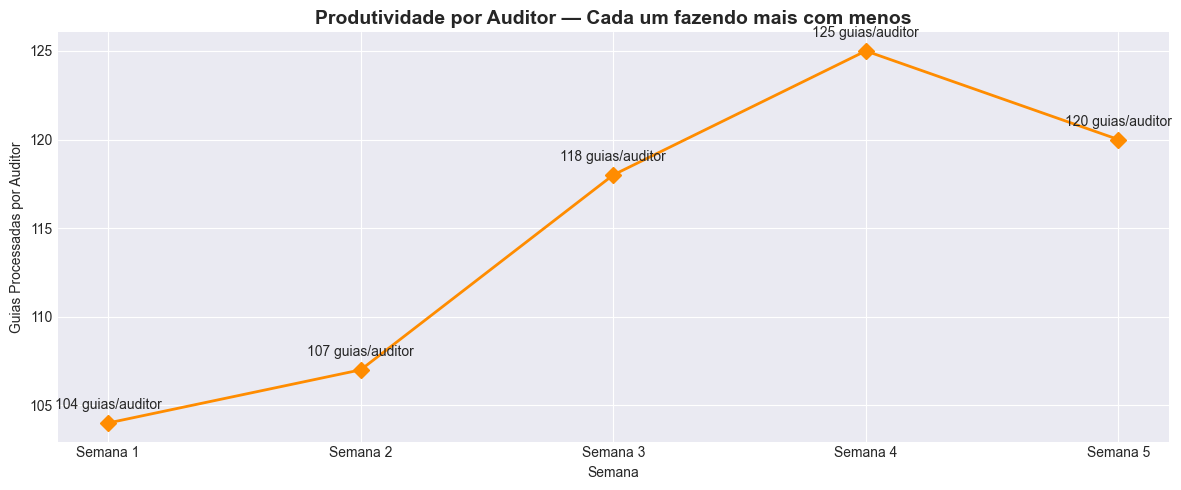

In [90]:
# Análise de Produtividade por Auditor
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_eng['Semana'], df_eng['Produtividade_Por_Auditor'], 
        color='darkorange', marker='D', linewidth=2, markersize=8)
for i, val in enumerate(df_eng['Produtividade_Por_Auditor']):
    ax.annotate(f'{val} guias/auditor', (df_eng['Semana'][i], val),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
ax.set_title('Produtividade por Auditor — Cada um fazendo mais com menos', fontsize=14, fontweight='bold')
ax.set_xlabel('Semana')
ax.set_ylabel('Guias Processadas por Auditor')
plt.tight_layout()
plt.show()
